In [1]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as img
import matplotlib.patches as patches
from tqdm import tqdm

from glob import glob
import os

import platform

In [2]:
# 윈도우 한글 폰트 설정 코드

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else: # Linux
    plt.rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print(f"현재 설정된 폰트: {plt.rcParams['font.family']}")

현재 설정된 폰트: ['Malgun Gothic']


In [3]:
# 윈도우 실제 경로(다운 받은 파일 경로)를 그대로 복사하되, 앞에 r을 꼭 붙여주세요.
actual_path = r'./data/train_annotations'


# recursive = True를 쓰면 하위 폴더를 모두 뒤져서 찾습니다.

json_files = glob(os.path.join(actual_path, '**', '*.json'), recursive=True)

print(f'찾은 총 json 파일 개수 : {len(json_files)}')

# 파일이 있는 경우, 첫 번째 파일의 경로를 출력해서 잘 찾았는지 확인
if json_files:
    print(f'첫 번째 파일 샘플 경로 : {json_files[0]}')

    # 구조 확인용
    with open(json_files[0], 'r', encoding='utf-8') as f:
        sample = json.load(f)
    print("\n--- JSON 데이터 구조(Key) ---")
    print(sample.keys())

찾은 총 json 파일 개수 : 763
첫 번째 파일 샘플 경로 : ./data/train_annotations\K-001900-016548-019607-029451_json\K-001900\K-001900-016548-019607-029451_0_2_0_2_70_000_200.json

--- JSON 데이터 구조(Key) ---
dict_keys(['images', 'type', 'annotations', 'categories'])


In [4]:
# 모든 행, 열 표시
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [5]:
all_rows = []

for file_path in tqdm(json_files, desc='상세 메타데이터 수집 중'):
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

        # 이미지 메타데이터(40개 클래스)
        img_metadata = data['images'][0]

        # 카테고리 이름 매핑
        cat_map = {cat['id']: cat['name'] for cat in data['categories']}

        # 어노테이션(BBox 등) 반복
        for anno in data['annotations']:
            # 어노테이션 정보 + 이미지 메타데이터 합치기
            combined_info = {**img_metadata, **anno} #dict 합치기

            # 카테고리 이름 추가
            combined_info['category_name'] = cat_map.get(anno['category_id'], 'unknown')
            combined_info['source_file'] = file_path

            all_rows.append(combined_info)

# 전체 통합 데이터프레임 생성
df_total = pd.DataFrame(all_rows)

print(f'통합 데이터프레임 형태: {df_total.shape}') # (행, 열) 확인
df_total.head()

상세 메타데이터 수집 중: 100%|██████████| 763/763 [00:00<00:00, 15086.78it/s]

통합 데이터프레임 형태: (763, 59)


,file_name,width,height,imgfile,drug_N,drug_S,back_color,drug_dir,light_color,camera_la,camera_lo,size,dl_idx,dl_mapping_code,dl_name,dl_name_en,img_key,dl_material,dl_material_en,dl_custom_shape,dl_company,dl_company_en,di_company_mf,di_company_mf_en,item_seq,di_item_permit_date,di_class_no,di_etc_otc_code,di_edi_code,chart,drug_shape,thick,leng_long,leng_short,print_front,print_back,color_class1,color_class2,line_front,line_back,img_regist_ts,form_code_name,mark_code_front_anal,mark_code_back_anal,mark_code_front_img,mark_code_back_img,mark_code_front,mark_code_back,change_date,id,area,iscrowd,bbox,category_id,ignore,segmentation,image_id,category_name,source_file
0,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,976,1280,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,K-001900,정상알약,연회색 배경,앞면,주백색,70,0,200,1900,K-001900,보령부스파정 5mg,Buspar Tab. 5mg Boryung,http://connectdi.com/design/img/drug/1Mxwka5v0...,부스피론염산염,Buspirone Hydrochloride,"정제, 저작정",보령제약(주),Boryung,,,198700706,19870323,[01170]정신신경용제,전문의약품,"641901280,A09302381",이약은 양면볼록한 장방형의 흰색정제이다,장방형,2.5,8.0,4.5,BSP,5,하양,,,,20070910,나정,,,,,,,20160825,133,35910,0,"[644, 845, 189, 190]",1900,0,[],34,보령부스파정 5mg,./data/train_annotations\K-001900-016548-01960...
1,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,976,1280,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,K-001900,정상알약,연회색 배경,앞면,주백색,75,0,200,1900,K-001900,보령부스파정 5mg,Buspar Tab. 5mg Boryung,http://connectdi.com/design/img/drug/1Mxwka5v0...,부스피론염산염,Buspirone Hydrochloride,"정제, 저작정",보령제약(주),Boryung,,,198700706,19870323,[01170]정신신경용제,전문의약품,"641901280,A09302381",이약은 양면볼록한 장방형의 흰색정제이다,장방형,2.5,8.0,4.5,BSP,5,하양,,,,20070910,나정,,,,,,,20160825,134,32761,0,"[148, 241, 181, 181]",1900,0,[],35,보령부스파정 5mg,./data/train_annotations\K-001900-016548-01960...
2,K-001900-016548-019607-029451_0_2_0_2_90_000_2...,976,1280,K-001900-016548-019607-029451_0_2_0_2_90_000_2...,K-001900,정상알약,연회색 배경,앞면,주백색,90,0,200,1900,K-001900,보령부스파정 5mg,Buspar Tab. 5mg Boryung,http://connectdi.com/design/img/drug/1Mxwka5v0...,부스피론염산염,Buspirone Hydrochloride,"정제, 저작정",보령제약(주),Boryung,,,198700706,19870323,[01170]정신신경용제,전문의약품,"641901280,A09302381",이약은 양면볼록한 장방형의 흰색정제이다,장방형,2.5,8.0,4.5,BSP,5,하양,,,,20070910,나정,,,,,,,20160825,135,33488,0,"[167, 248, 184, 182]",1900,0,[],36,보령부스파정 5mg,./data/train_annotations\K-001900-016548-01960...
3,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,976,1280,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,K-016548,정상알약,연회색 배경,앞면,주백색,70,0,200,16548,K-016548,가바토파정 100mg,Gabatopa Tab. 100mg,None,토피라메이트,Topiramate,"정제, 저작정",동아에스티(주),Dong-A St,,,200500251,20050628,[01130]항전간제,전문의약품,"642500020,A01508461",None,None,0.0,0.0,0.0,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,136,57121,0,"[144, 799, 239, 239]",16548,0,[],34,가바토파정 100mg,./data/train_annotations\K-001900-016548-01960...
4,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,976,1280,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,K-016548,정상알약,연회색 배경,앞면,주백색,75,0,200,16548,K-016548,가바토파정 100mg,Gabatopa Tab. 100mg,None,토피라메이트,Topiramate,"정제, 저작정",동아에스티(주),Dong-A St,,,200500251,20050628,[01130]항전간제,전문의약품,"642500020,A01508461",None,None,0.0,0.0,0.0,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,137,52658,0,"[578, 222, 233, 226]",16548,0,[],35,가바토파정 100mg,./data/train_annotations\K-001900-016548-01960...


In [6]:
df_total['bbox_tuple'] = df_total['bbox'].apply(tuple)

dup = df_total[df_total.duplicated(
    subset=['file_name', 'bbox_tuple'],
    keep=False
)]

len(dup)

6

In [7]:
# 어떤 데이터가 중복인지 상세 확인
print("--- [중복 데이터 상세 목록] ---")
display(dup.sort_values(by=['file_name', 'bbox_tuple']))

--- [중복 데이터 상세 목록] ---


,file_name,width,height,imgfile,drug_N,drug_S,back_color,drug_dir,light_color,camera_la,camera_lo,size,dl_idx,dl_mapping_code,dl_name,dl_name_en,img_key,dl_material,dl_material_en,dl_custom_shape,dl_company,dl_company_en,di_company_mf,di_company_mf_en,item_seq,di_item_permit_date,di_class_no,di_etc_otc_code,di_edi_code,chart,drug_shape,thick,leng_long,leng_short,print_front,print_back,color_class1,color_class2,line_front,line_back,img_regist_ts,form_code_name,mark_code_front_anal,mark_code_back_anal,mark_code_front_img,mark_code_back_img,mark_code_front,mark_code_back,change_date,id,area,iscrowd,bbox,category_id,ignore,segmentation,image_id,category_name,source_file,bbox_tuple
15,K-001900-016548-019607-033009_0_2_0_2_70_000_2...,976,1280,K-001900-016548-019607-033009_0_2_0_2_70_000_2...,K-016548,정상알약,연회색 배경,앞면,주백색,70,0,200,16548,K-016548,가바토파정 100mg,Gabatopa Tab. 100mg,None,토피라메이트,Topiramate,"정제, 저작정",동아에스티(주),Dong-A St,,,200500251,20050628,[01130]항전간제,전문의약품,"642500020,A01508461",None,None,0.00,0.00,0.00,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,4683,76494,0,"[88, 255, 366, 209]",16548,0,[],1228,가바토파정 100mg,./data/train_annotations\K-001900-016548-01960...,"(88, 255, 366, 209)"
21,K-001900-016548-019607-033009_0_2_0_2_70_000_2...,976,1280,K-001900-016548-019607-033009_0_2_0_2_70_000_2...,K-033009,정상알약,연회색 배경,앞면,주백색,70,0,200,33009,K-033009,신바로정,Shinbaro Tab.,http://connectdi.com/design/img/drug/148431162...,자오가·우슬·방풍·두충·구척·흑두건조엑스,Acanthopanax·Achyranthes·Ledebouriella etc Dri...,"정제, 저작정",(주)녹십자,Green Cross Corp,,,201401963,20140423,[01140]해열.진통.소염제,전문의약품,643605030,갈색의 장방형 필름코팅정,타원형,5.30,14.50,8.00,S300,,갈색,,,,20140925,필름코팅정,,,,,,,20151015,4691,76494,0,"[88, 255, 366, 209]",33009,0,[],1228,신바로정,./data/train_annotations\K-001900-016548-01960...,"(88, 255, 366, 209)"
420,K-003351-020238-031863_0_2_0_2_70_000_200.png,976,1280,K-003351-020238-031863_0_2_0_2_70_000_200.png,K-003351,정상알약,연회색 배경,앞면,주백색,70,0,200,3351,K-003351,일양하이트린정 2mg,Hytrin Tab. 2mg Ilyang,http://connectdi.com/design/img/drug/147765842...,테라조신염산염수화물,Terazosin Hydrochloride Hydrate,"정제, 저작정",일양약품(주),Ilyang Pharmaceutical,,,199101125,19910626,[02590]기타의 비뇨생식기관 및 항문용약,전문의약품,"641702010,A09503981",오랜지색 또는 노란색의 원형정제.,원형,2.76,7.01,7.01,I분할선Y,HT,주황,,-,,20041222,나정,,,,,,,20170328,3444,36290,0,"[446, 844, 190, 191]",3351,0,[],907,일양하이트린정 2mg,./data/train_annotations\K-003351-020238-03186...,"(446, 844, 190, 191)"
422,K-003351-020238-031863_0_2_0_2_70_000_200.png,976,1280,K-003351-020238-031863_0_2_0_2_70_000_200.png,K-020238,정상알약,연회색 배경,앞면,주백색,70,0,200,20238,K-020238,플라빅스정 75mg,Plavix Tab. 75mg,http://connectdi.com/design/img/drug/149883724...,클로피도그렐황산염,Clopidogrel Bisulfate,"정제, 저작정",(주)한독,Handok,Sanofi Winthrop Industrie,,200700907,20070122,[02180]동맥경화용제,전문의약품,"652101570,A07404851",분홍색의 원형필름코팅정,원형,4.00,8.50,8.50,75,1171,분홍,,,,20041222,필름코팅정,,,,,,,20210426,3441,36290,0,"[446, 844, 190, 191]",20238,0,[],907,플라빅스정 75mg,./data/train_annotations\K-003351-020238-03186...,"(446, 844, 190, 191)"
485,K-003351-029667-031863_0_2_0_2_70_000_200.png,976,1280,K-003351-029667-031863_0_2_0_2_70_000_200.png,K-003351,정상알약,연회색 배경,앞면,주백색,70,0,200,3351,K-003351,일양하이트린정 2mg,Hytrin Tab. 2mg Ilyang,http://connectdi.com/design/img/drug/147765842...,테라조신염산염수화물,Terazosin Hydrochloride Hydrate,"정제, 저작정",일양약품(주),Ilyang Pharmaceutical,,,199101125,19910626,[02590]기타의 비뇨생식기관 및 항문용약,전문의약품,"641702010,A09503981",오랜지색 또는 노란색의 원형정제.,원형,2.76,7.01,7.01,I분할선Y,HT,주황,,-,,20041222,나정,,,,,,,20170328,791,41615,0,"[178, 249, 205, 203]",3351,0,[],208,일양하이트린정 2mg,./data/train_annotations\K-003351-029667-03186...,"(178, 249, 205, 203)"
489,K-003351-029667-031863_0_2_0_2_70_000_200.png,976,1280,K-003351-029667-031863_0_2_0_2_70_000_200.png,K-031863,정상알약,연회색 배경,앞면,주백색,70,0,200,31863,K-031863,아질렉트정(라사길린메실산염),Azilect Tab.,http://connectdi.com/design/img/drug/147426780...,라사길린메실산염,Rasagiline Mesylate,"정제, 저작정",한국룬드벡(주),Lundbeck Korea,Teva Pharmaceutical Industries Ltd.,,201309347,20130913,[011

## 15) 중복 의심 bbox 탐지 & 시각화 (새 df 기반)

⚠️ 이 섹션은 **이 노트북에서 새로 생성한 df만을 사용**합니다.  
이전 노트북의 `obj_df / obj_df_qc`에는 의존하지 않습니다.

목표:
- 동일 이미지 내 **중복 또는 거의 동일한 bbox** 탐지
- 실제 이미지 위에 시각화하여 **라벨링 오류 여부 확인**


In [8]:
# =========================
# 15-0) 새 df_total 기반 객체 단위 DF 구성 (스키마 확장 대응)
# =========================
import pandas as pd
import numpy as np

# ✅ 사용자가 최종 생성한 DF 이름: df_total
if "df_total" not in globals() or not isinstance(df_total, pd.DataFrame) or len(df_total) == 0:
    raise ValueError("df_total(DataFrame)을 찾지 못했거나 비어있습니다. 앞 셀에서 df_total을 생성한 뒤 다시 실행해 주세요.")

SRC_DF = df_total
print("Using dataframe: df_total | shape=", SRC_DF.shape)
print("df_total columns:", list(SRC_DF.columns))

def _is_xywh_list(x):
    return isinstance(x, (list, tuple)) and len(x) == 4 and all(isinstance(v, (int, float, np.number)) for v in x)

def _maybe_parse_listlike(x):
    # 문자열로 들어온 리스트(예: "[1,2,3,4]") 대응(안전하게 eval 대신 json 유사만 처리)
    if isinstance(x, str):
        s = x.strip()
        if s.startswith("[") and s.endswith("]"):
            try:
                import ast
                v = ast.literal_eval(s)
                return v
            except Exception:
                return x
    return x

def build_use_obj_from_df(df_):
    """df_total 스키마가 달라도 객체 단위 USE_OBJ를 최대한 구성합니다.

    지원 케이스:
    1) 객체 단위: file_name,x,y,w,h 존재
    2) 이미지 단위: bboxes(list[[x,y,w,h],...]) 존재
    3) 객체 단위: bbox(list[4]) 컬럼 존재 (COCO bbox)
    4) 이미지 단위: annotations(list[dict]) 또는 ann/objs(list[dict]) 컬럼 내에 bbox 키가 존재
    """

    # Case 1) 객체 단위 (x,y,w,h)
    if {"file_name","x","y","w","h"}.issubset(df_.columns):
        use_obj = df_.copy()
        if "label_name" not in use_obj.columns:
            use_obj["label_name"] = use_obj.get("label", use_obj.get("category_name", "(no_label)"))
        if "img_w" not in use_obj.columns and "width" in use_obj.columns:
            use_obj["img_w"] = use_obj["width"]
        if "img_h" not in use_obj.columns and "height" in use_obj.columns:
            use_obj["img_h"] = use_obj["height"]
        return use_obj.reset_index(drop=True)

    # Case 2) 이미지 단위 + bboxes(list)
    if "bboxes" in df_.columns:
        rows = []
        for _, r in df_.iterrows():
            bbs = r.get("bboxes", [])
            bbs = _maybe_parse_listlike(bbs)
            if not isinstance(bbs, list):
                continue
            for bb in bbs:
                bb = _maybe_parse_listlike(bb)
                if not _is_xywh_list(bb):
                    continue
                rows.append({
                    "file_name": r.get("file_name"),
                    "label_name": r.get("label_name", r.get("label", r.get("category_name","(no_label)"))),
                    "x": float(bb[0]), "y": float(bb[1]), "w": float(bb[2]), "h": float(bb[3]),
                    "img_w": r.get("width", r.get("img_w", np.nan)),
                    "img_h": r.get("height", r.get("img_h", np.nan)),
                })
        return pd.DataFrame(rows)

    # Case 3) 객체 단위 + bbox(list[4])
    if {"file_name","bbox"}.issubset(df_.columns):
        use_obj = df_.copy()
        use_obj["bbox"] = use_obj["bbox"].apply(_maybe_parse_listlike)
        ok = use_obj["bbox"].apply(_is_xywh_list)
        use_obj = use_obj[ok].copy()
        if len(use_obj) == 0:
            raise ValueError("df_total에 bbox 컬럼은 있으나 유효한 list[4] bbox를 찾지 못했습니다.")
        use_obj["x"] = use_obj["bbox"].apply(lambda b: float(b[0]))
        use_obj["y"] = use_obj["bbox"].apply(lambda b: float(b[1]))
        use_obj["w"] = use_obj["bbox"].apply(lambda b: float(b[2]))
        use_obj["h"] = use_obj["bbox"].apply(lambda b: float(b[3]))
        if "label_name" not in use_obj.columns:
            use_obj["label_name"] = use_obj.get("label", use_obj.get("category_name", "(no_label)"))
        if "img_w" not in use_obj.columns and "width" in use_obj.columns:
            use_obj["img_w"] = use_obj["width"]
        if "img_h" not in use_obj.columns and "height" in use_obj.columns:
            use_obj["img_h"] = use_obj["height"]
        return use_obj.reset_index(drop=True)

    # Case 4) 이미지 단위 + annotations(list[dict]) 류
    cand_ann_cols = [c for c in ["annotations","ann","anns","objects","objs","labels"] if c in df_.columns]
    if cand_ann_cols:
        ann_col = cand_ann_cols[0]
        rows = []
        for _, r in df_.iterrows():
            ann_list = r.get(ann_col, [])
            ann_list = _maybe_parse_listlike(ann_list)
            if not isinstance(ann_list, list):
                continue
            for ann in ann_list:
                ann = _maybe_parse_listlike(ann)
                if not isinstance(ann, dict):
                    continue
                bb = ann.get("bbox", None)
                bb = _maybe_parse_listlike(bb)
                if not _is_xywh_list(bb):
                    continue
                rows.append({
                    "file_name": r.get("file_name"),
                    "label_name": ann.get("label_name", ann.get("name", ann.get("category_name", r.get("label_name","(no_label)")))),
                    "x": float(bb[0]), "y": float(bb[1]), "w": float(bb[2]), "h": float(bb[3]),
                    "img_w": r.get("width", r.get("img_w", np.nan)),
                    "img_h": r.get("height", r.get("img_h", np.nan)),
                })
        use_obj = pd.DataFrame(rows)
        if len(use_obj) > 0:
            return use_obj

    # 여기까지 왔다면 스키마가 예상 밖
    # 디버깅에 도움이 되도록 샘플을 보여줌
    display(df_.head(3))
    raise ValueError(
        "df_total에서 객체 단위 bbox를 구성할 수 없습니다.\n"
        "현재 지원: (file_name,x,y,w,h) / bboxes(list) / bbox(list[4]) / annotations(list[dict] with bbox).\n"
        "df_total.columns와 head(3)를 위에 출력했으니, bbox가 들어있는 컬럼명을 확인해 주세요."
    )

USE_OBJ = build_use_obj_from_df(SRC_DF)

print("USE_OBJ shape:", USE_OBJ.shape)
display(USE_OBJ.head())


Using dataframe: df_total | shape= (763, 60)
df_total columns: ['file_name', 'width', 'height', 'imgfile', 'drug_N', 'drug_S', 'back_color', 'drug_dir', 'light_color', 'camera_la', 'camera_lo', 'size', 'dl_idx', 'dl_mapping_code', 'dl_name', 'dl_name_en', 'img_key', 'dl_material', 'dl_material_en', 'dl_custom_shape', 'dl_company', 'dl_company_en', 'di_company_mf', 'di_company_mf_en', 'item_seq', 'di_item_permit_date', 'di_class_no', 'di_etc_otc_code', 'di_edi_code', 'chart', 'drug_shape', 'thick', 'leng_long', 'leng_short', 'print_front', 'print_back', 'color_class1', 'color_class2', 'line_front', 'line_back', 'img_regist_ts', 'form_code_name', 'mark_code_front_anal', 'mark_code_back_anal', 'mark_code_front_img', 'mark_code_back_img', 'mark_code_front', 'mark_code_back', 'change_date', 'id', 'area', 'iscrowd', 'bbox', 'category_id', 'ignore', 'segmentation', 'image_id', 'category_name', 'source_file', 'bbox_tuple']
USE_OBJ shape: (763, 67)


,file_name,width,height,imgfile,drug_N,drug_S,back_color,drug_dir,light_color,camera_la,camera_lo,size,dl_idx,dl_mapping_code,dl_name,dl_name_en,img_key,dl_material,dl_material_en,dl_custom_shape,dl_company,dl_company_en,di_company_mf,di_company_mf_en,item_seq,di_item_permit_date,di_class_no,di_etc_otc_code,di_edi_code,chart,drug_shape,thick,leng_long,leng_short,print_front,print_back,color_class1,color_class2,line_front,line_back,img_regist_ts,form_code_name,mark_code_front_anal,mark_code_back_anal,mark_code_front_img,mark_code_back_img,mark_code_front,mark_code_back,change_date,id,area,iscrowd,bbox,category_id,ignore,segmentation,image_id,category_name,source_file,bbox_tuple,x,y,w,h,label_name,img_w,img_h
0,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,976,1280,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,K-001900,정상알약,연회색 배경,앞면,주백색,70,0,200,1900,K-001900,보령부스파정 5mg,Buspar Tab. 5mg Boryung,http://connectdi.com/design/img/drug/1Mxwka5v0...,부스피론염산염,Buspirone Hydrochloride,"정제, 저작정",보령제약(주),Boryung,,,198700706,19870323,[01170]정신신경용제,전문의약품,"641901280,A09302381",이약은 양면볼록한 장방형의 흰색정제이다,장방형,2.5,8.0,4.5,BSP,5,하양,,,,20070910,나정,,,,,,,20160825,133,35910,0,"[644, 845, 189, 190]",1900,0,[],34,보령부스파정 5mg,./data/train_annotations\K-001900-016548-01960...,"(644, 845, 189, 190)",644.0,845.0,189.0,190.0,보령부스파정 5mg,976,1280
1,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,976,1280,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,K-001900,정상알약,연회색 배경,앞면,주백색,75,0,200,1900,K-001900,보령부스파정 5mg,Buspar Tab. 5mg Boryung,http://connectdi.com/design/img/drug/1Mxwka5v0...,부스피론염산염,Buspirone Hydrochloride,"정제, 저작정",보령제약(주),Boryung,,,198700706,19870323,[01170]정신신경용제,전문의약품,"641901280,A09302381",이약은 양면볼록한 장방형의 흰색정제이다,장방형,2.5,8.0,4.5,BSP,5,하양,,,,20070910,나정,,,,,,,20160825,134,32761,0,"[148, 241, 181, 181]",1900,0,[],35,보령부스파정 5mg,./data/train_annotations\K-001900-016548-01960...,"(148, 241, 181, 181)",148.0,241.0,181.0,181.0,보령부스파정 5mg,976,1280
2,K-001900-016548-019607-029451_0_2_0_2_90_000_2...,976,1280,K-001900-016548-019607-029451_0_2_0_2_90_000_2...,K-001900,정상알약,연회색 배경,앞면,주백색,90,0,200,1900,K-001900,보령부스파정 5mg,Buspar Tab. 5mg Boryung,http://connectdi.com/design/img/drug/1Mxwka5v0...,부스피론염산염,Buspirone Hydrochloride,"정제, 저작정",보령제약(주),Boryung,,,198700706,19870323,[01170]정신신경용제,전문의약품,"641901280,A09302381",이약은 양면볼록한 장방형의 흰색정제이다,장방형,2.5,8.0,4.5,BSP,5,하양,,,,20070910,나정,,,,,,,20160825,135,33488,0,"[167, 248, 184, 182]",1900,0,[],36,보령부스파정 5mg,./data/train_annotations\K-001900-016548-01960...,"(167, 248, 184, 182)",167.0,248.0,184.0,182.0,보령부스파정 5mg,976,1280
3,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,976,1280,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,K-016548,정상알약,연회색 배경,앞면,주백색,70,0,200,16548,K-016548,가바토파정 100mg,Gabatopa Tab. 100mg,None,토피라메이트,Topiramate,"정제, 저작정",동아에스티(주),Dong-A St,,,200500251,20050628,[01130]항전간제,전문의약품,"642500020,A01508461",None,None,0.0,0.0,0.0,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,136,57121,0,"[144, 799, 239, 239]",16548,0,[],34,가바토파정 100mg,./data/train_annotations\K-001900-016548-01960...,"(144, 799, 239, 239)",144.0,799.0,239.0,239.0,가바토파정 100mg,976,1280
4,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,976,1280,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,K-016548,정상알약,연회색 배경,앞면,주백색,75,0,200,16548,K-016548,가바토파정 100mg,Gabatopa Tab. 100mg,None,토피라메이트,Topiramate,"정제, 저작정",동아에스티(주),Dong-A St,,,200500251,20050628,[01130]항전간제,전문의약품,"642500020,A01508461",None,None,0.0,0.0,0.0,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,137,52658,0,"[578, 222, 233, 226]",16548,0,[],35,가바토파정 100mg,./data/train_annotations\K-001900-016548-01960...,"(578, 222, 233, 226)",578.0,222.0,233.0,226.0,가바토파정 100mg,976,1280


In [9]:
# =========================
# 15-1) IoU 계산 유틸 (+ round_bbox)
# =========================
import numpy as np

def bbox_xywh_to_xyxy(bb):
    x,y,w,h = bb
    return x, y, x+w, y+h

def iou_xywh(bb1, bb2):
    x1,y1,x2,y2 = bbox_xywh_to_xyxy(bb1)
    x1b,y1b,x2b,y2b = bbox_xywh_to_xyxy(bb2)

    ix1, iy1 = max(x1,x1b), max(y1,y1b)
    ix2, iy2 = min(x2,x2b), min(y2,y2b)
    iw, ih = max(0, ix2-ix1), max(0, iy2-iy1)

    inter = iw * ih
    area1 = max(0,x2-x1) * max(0,y2-y1)
    area2 = max(0,x2b-x1b) * max(0,y2b-y1b)
    union = area1 + area2 - inter
    return inter/union if union>0 else 0.0

def round_bbox(bb, ndigits=2):
    """소수/타입 혼재를 대비해 bbox([x,y,w,h])를 라운딩 튜플로 변환"""
    return tuple([round(float(v), ndigits) for v in bb])


In [10]:
# =========================
# 15-2) 중복 의심 bbox 탐지 (df_total → USE_OBJ 기반, 에러 방지 버전)
# =========================
import pandas as pd
import numpy as np

# 15-0 셀에서 USE_OBJ가 생성되어 있어야 합니다.
if "USE_OBJ" not in globals() or USE_OBJ is None or len(USE_OBJ) == 0:
    raise ValueError("USE_OBJ가 없습니다. 15-0 셀을 먼저 실행해서 df_total → USE_OBJ를 생성해 주세요.")

# 필요한 컬럼 체크
need_cols = ["file_name","x","y","w","h","label_name"]
missing = [c for c in need_cols if c not in USE_OBJ.columns]
if missing:
    raise ValueError(f"USE_OBJ에 필요한 컬럼이 없습니다: {missing}\n현재 columns={list(USE_OBJ.columns)[:80]}")

# bbox 파생 컬럼 생성 (항상 여기서 생성 → bbox_rnd에서 KeyError/NameError 방지)
USE_OBJ = USE_OBJ.copy().reset_index(drop=True)
USE_OBJ["bbox_xywh"] = USE_OBJ[["x","y","w","h"]].apply(
    lambda r: [float(r[0]), float(r[1]), float(r[2]), float(r[3])],
    axis=1
)
USE_OBJ["bbox_rnd"] = USE_OBJ["bbox_xywh"].apply(lambda bb: round_bbox(bb, ndigits=2))

def find_duplicate_bboxes_per_image(obj_df, iou_thr=0.98):
    rows = []
    for fname, g in obj_df.groupby("file_name"):
        bbs = g["bbox_xywh"].tolist()
        idxs = list(g.index)
        labels = g["label_name"].tolist()

        # 1) 완전 중복(라운딩 기준)
        dup_groups = {}
        for k, bb in zip(idxs, g["bbox_rnd"].tolist()):
            dup_groups.setdefault(bb, []).append(k)

        for bb_key, ids in dup_groups.items():
            if len(ids) >= 2:
                rows.append({
                    "file_name": fname,
                    "dup_type": "exact(rounded)",
                    "group_size": len(ids),
                    "indices": ids,
                    "labels": [obj_df.loc[i, "label_name"] for i in ids],
                    "bbox_key": bb_key,
                    "max_iou_in_group": 1.0,
                })

        # 2) 준-중복(IoU)
        n = len(bbs)
        if n >= 2:
            for i in range(n):
                for j in range(i+1, n):
                    iou = iou_xywh(bbs[i], bbs[j])
                    if iou >= iou_thr:
                        rows.append({
                            "file_name": fname,
                            "dup_type": f"near(iou>={iou_thr})",
                            "group_size": 2,
                            "indices": [idxs[i], idxs[j]],
                            "labels": [labels[i], labels[j]],
                            "bbox_key": None,
                            "max_iou_in_group": float(iou),
                        })
    return pd.DataFrame(rows)

dup_df = find_duplicate_bboxes_per_image(USE_OBJ, iou_thr=0.98)

print("duplicate-suspect rows:", len(dup_df))
display(dup_df.head(50))


duplicate-suspect rows: 6


C:\Users\TAEHO\AppData\Local\Temp\ipykernel_35848\3178068353.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda r: [float(r[0]), float(r[1]), float(r[2]), float(r[3])],


,file_name,dup_type,group_size,indices,labels,bbox_key,max_iou_in_group
0,K-001900-016548-019607-033009_0_2_0_2_70_000_2...,exact(rounded),2,"[15, 21]","[가바토파정 100mg, 신바로정]","(88.0, 255.0, 366.0, 209.0)",1.0
1,K-001900-016548-019607-033009_0_2_0_2_70_000_2...,near(iou>=0.98),2,"[15, 21]","[가바토파정 100mg, 신바로정]",None,1.0
2,K-003351-020238-031863_0_2_0_2_70_000_200.png,exact(rounded),2,"[420, 422]","[일양하이트린정 2mg, 플라빅스정 75mg]","(446.0, 844.0, 190.0, 191.0)",1.0
3,K-003351-020238-031863_0_2_0_2_70_000_200.png,near(iou>=0.98),2,"[420, 422]","[일양하이트린정 2mg, 플라빅스정 75mg]",None,1.0
4,K-003351-029667-031863_0_2_0_2_70_000_200.png,exact(rounded),2,"[485, 489]","[일양하이트린정 2mg, 아질렉트정(라사길린메실산염)]","(178.0, 249.0, 205.0, 203.0)",1.0
5,K-003351-029667-031863_0_2_0_2_70_000_200.png,near(iou>=0.98),2,"[485, 489]","[일양하이트린정 2mg, 아질렉트정(라사길린메실산염)]",None,1.0


In [16]:
# =========================
# 15-3) 중복 의심 bbox 시각화 (메모리 안전 버전)
#   - 큰 원본 이미지는 자동 리사이즈(기본 max_side=1024)
#   - dup_df 스키마: `indices`(list) 지원
# =========================
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
from pathlib import Path
import numpy as np

# 예) IMG_ROOT = Path("./data/train_images")
# 이미지가 없거나 None이면 캔버스에 bbox만 표시
IMG_ROOT = Path("./data/train_images")

def _get_highlight_indices(d_sub):
    hi = set()
    if "indices" in d_sub.columns:
        for ids in d_sub["indices"].tolist():
            if isinstance(ids, list):
                for x in ids:
                    try:
                        hi.add(int(x))
                    except Exception:
                        hi.add(x)
    else:
        if "idx_a" in d_sub.columns: hi.update(d_sub["idx_a"].tolist())
        if "idx_b" in d_sub.columns: hi.update(d_sub["idx_b"].tolist())
    return hi

def _load_and_resize_image(img_path: Path, max_side: int = 1024):
    """메모리 폭주 방지를 위해 max_side 기준으로 리사이즈. 리사이즈 비율(sx,sy) 반환."""
    img = Image.open(img_path).convert("RGB")
    W, H = img.size
    scale = min(1.0, max_side / max(W, H))
    if scale < 1.0:
        newW, newH = int(W * scale), int(H * scale)
        img = img.resize((newW, newH), resample=Image.BILINEAR)
        return img, scale, scale
    return img, 1.0, 1.0

def show_duplicates_for_image(file_name, *, max_side=1024, figsize=7, dpi=100, max_boxes=200):
    """중복 의심 bbox가 있는 한 이미지를 메모리 안전하게 시각화합니다."""
    g = USE_OBJ[USE_OBJ["file_name"] == file_name].copy()
    d = dup_df[dup_df["file_name"] == file_name].copy()

    if len(g) == 0:
        print("객체 없음:", file_name)
        return
    if len(d) == 0:
        print("중복 의심 없음:", file_name)
        return

    # 너무 많은 bbox가 있으면 렌더링이 무거워질 수 있어 제한
    if len(g) > max_boxes:
        g = g.sample(max_boxes, random_state=0).copy()

    fig, ax = plt.subplots(figsize=(figsize, figsize), dpi=dpi)

    sx = sy = 1.0
    # 이미지가 있으면 이미지 위에, 없으면 캔버스
    if isinstance(IMG_ROOT, Path):
        img_path = IMG_ROOT / file_name
        if img_path.exists():
            img, sx, sy = _load_and_resize_image(img_path, max_side=max_side)
            ax.imshow(img)
        else:
            # fall back to canvas
            pass

    if not (isinstance(IMG_ROOT, Path) and (IMG_ROOT / file_name).exists()):
        # 캔버스 크기
        W = int(g["img_w"].dropna().iloc[0]) if ("img_w" in g.columns and g["img_w"].notna().any()) else 1000
        H = int(g["img_h"].dropna().iloc[0]) if ("img_h" in g.columns and g["img_h"].notna().any()) else 1000
        # 캔버스도 max_side 기준으로 축소해서 표시(좌표 스케일 맞춤)
        scale = min(1.0, max_side / max(W, H))
        sx = sy = scale
        ax.set_xlim(0, W * scale)
        ax.set_ylim(H * scale, 0)

    hi = _get_highlight_indices(d)

    # bbox 그리기(스케일 적용)
    for idx, r in g.iterrows():
        x = float(r.x) * sx
        y = float(r.y) * sy
        w = float(r.w) * sx
        h = float(r.h) * sy

        rect = Rectangle(
            (x, y), w, h,
            linewidth=2 if idx in hi else 1,
            edgecolor="red" if idx in hi else "blue",
            fill=False
        )
        ax.add_patch(rect)
        ax.text(x, y, f"{idx}:{r.get('label_name','')}", fontsize=8)

    ax.set_title(f"{file_name} | dup_cases={len(d)} | shown_boxes={len(g)}")
    ax.axis("off")
    plt.show()


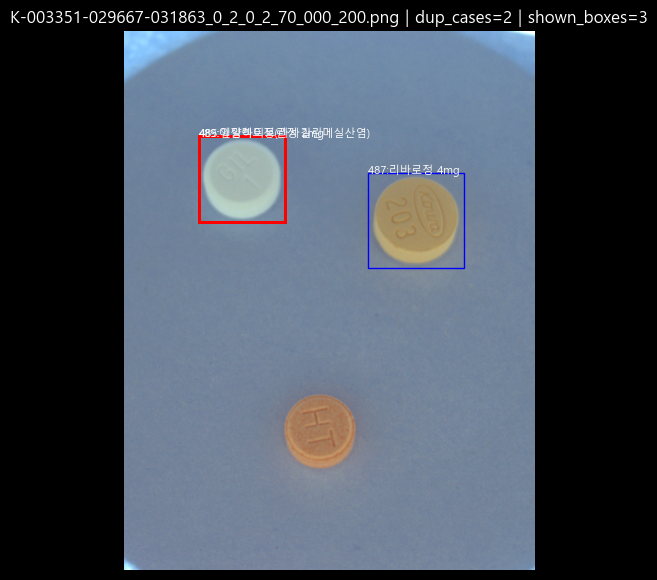

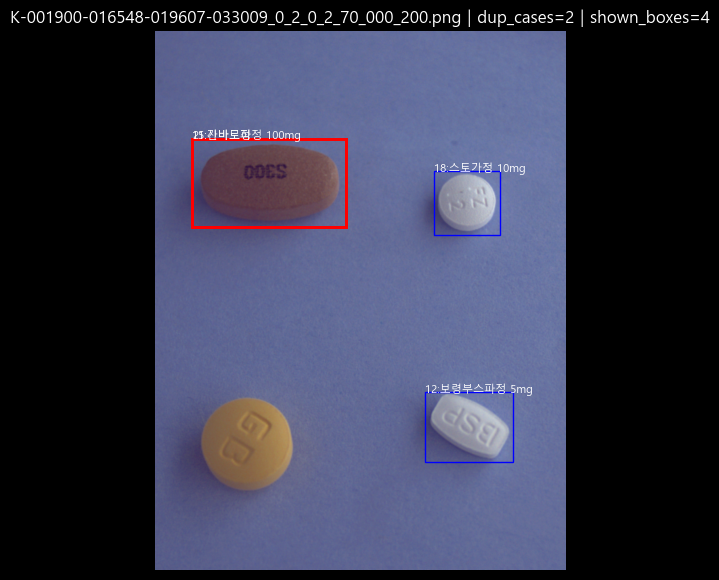

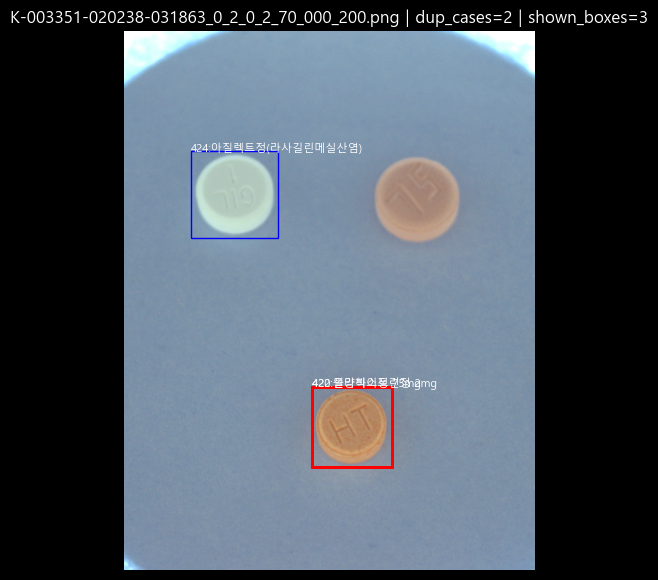

In [17]:
# =========================
# 15-4) 랜덤 중복 이미지 확인 (4장, 메모리 안전)
# =========================
import random

def show_random_dup_images(n=4, seed=42, **kwargs):
    if "dup_df" not in globals() or dup_df is None or len(dup_df) == 0:
        print("중복 의심 bbox 없음")
        return
    imgs = dup_df["file_name"].dropna().unique().tolist()
    if len(imgs) == 0:
        print("중복 의심 bbox 없음")
        return
    random.seed(seed)
    for fname in random.sample(imgs, k=min(n, len(imgs))):
        show_duplicates_for_image(fname, **kwargs)

# 실행 (큰 이미지면 max_side를 더 줄이세요: 768 / 512 등)
show_random_dup_images(n=4, seed=42, max_side=1024, figsize=7)
